# BrainInsight AI
# Notebook 06: Prediction

## Objectives
Predict the brain MRI class using the trained Random Forest model by reproducing the same preprocessing and feature extraction pipeline used during training.


In [2]:
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

PROJECT_ROOT=Path("..")
MODEL_DIR=PROJECT_ROOT/"saved_models"

model=joblib.load(MODEL_DIR/"random_forest.pkl")
scaler=joblib.load(MODEL_DIR/"scaler.pkl")
encoder=joblib.load(MODEL_DIR/"label_encoder.pkl")

TARGET_SIZE=(256,256)


In [3]:
def preprocess(img):
    img=cv2.resize(img,TARGET_SIZE)
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    gray=cv2.equalizeHist(gray)
    gray=cv2.GaussianBlur(gray,(5,5),0)
    _,gray=cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    k=np.ones((3,3),np.uint8)
    gray=cv2.morphologyEx(gray,cv2.MORPH_OPEN,k)
    gray=cv2.morphologyEx(gray,cv2.MORPH_CLOSE,k)
    return gray

def extract_features(gray):
    hog_feat=hog(gray,orientations=9,pixels_per_cell=(8,8),cells_per_block=(2,2),feature_vector=True)
    lbp=local_binary_pattern(gray,8,1,method="uniform")
    lbp_hist,_=np.histogram(lbp.ravel(),bins=np.arange(0,11),range=(0,10))
    lbp_hist=lbp_hist.astype(float)/(lbp_hist.sum()+1e-6)
    glcm=graycomatrix(gray,[1],[0],symmetric=True,normed=True)
    glcm_feat=[graycoprops(glcm,n)[0,0] for n in ["contrast","correlation","energy","homogeneity"]]
    hu=cv2.HuMoments(cv2.moments(gray)).flatten()
    _,b=cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    cnts,_=cv2.findContours(b,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c=max(cnts,key=cv2.contourArea)
        area=cv2.contourArea(c); peri=cv2.arcLength(c,True)
        circ=(4*np.pi*area)/(peri**2+1e-6)
        x,y,w,h=cv2.boundingRect(c); ar=w/(h+1e-6)
        hull=cv2.convexHull(c); sol=area/(cv2.contourArea(hull)+1e-6)
    else:
        area=peri=circ=ar=sol=0
    hist=cv2.calcHist([gray],[0],None,[32],[0,256]).flatten()
    hist=hist/(hist.sum()+1e-6)
    tex=[gray.mean(),gray.std(),gray.min(),gray.max()]
    return np.concatenate([hog_feat,lbp_hist,glcm_feat,hu,[area,peri,circ,ar,sol],hist,tex])

def predict_image(image_path):
    img=cv2.imread(str(image_path))
    if img is None:
        raise ValueError("Image not found.")
    proc=preprocess(img)
    feat=scaler.transform([extract_features(proc)])
    pred=model.predict(feat)[0]
    probs=model.predict_proba(feat)[0]
    label=encoder.inverse_transform([pred])[0]
    return img,label,float(np.max(probs))*100,probs


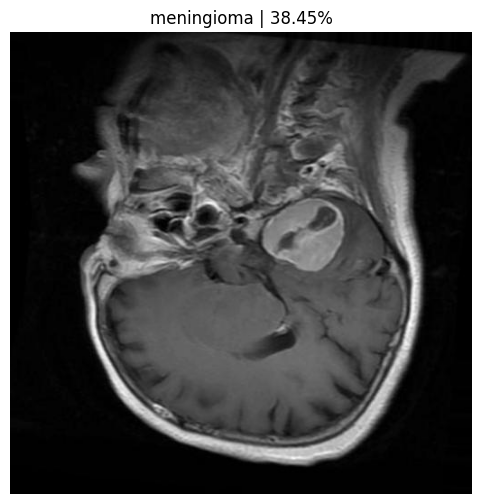

Prediction : meningioma
Confidence : 38.45%

Class Probabilities
glioma         : 32.60%
meningioma     : 38.45%
notumor        : 14.74%
pituitary      : 14.21%


In [4]:
# Replace with a valid MRI image
IMAGE_PATH=r"../dataset/Testing/meningioma/Te-aug-me_7.jpg"

image,label,confidence,probabilities=predict_image(IMAGE_PATH)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{label} | {confidence:.2f}%")
plt.show()

print("Prediction :",label)
print("Confidence :",f"{confidence:.2f}%")
print("\nClass Probabilities")
for cls,p in zip(encoder.classes_,probabilities):
    print(f"{cls:<15}: {p*100:.2f}%")


## Conclusion
The trained model successfully predicts the tumor category using the same preprocessing and handcrafted feature extraction pipeline used during model training.


## Interview Notes
- Why must inference use the same preprocessing pipeline?
- Why save the scaler?
- Why use `predict_proba()`?
- Why save the label encoder?
